### **Step 1 : Load and Inspect the Dataset**
##### **- We need to load the dataset and check its structure to understand what data is available**

In [2]:
import pandas as pd

# Path of the dataset
file_path = ("C:\\Users\\Admin\\Downloads\\API_SP.POP.TOTL_DS2_en_csv_v2_26346\\API_SP.POP.TOTL_DS2_en_csv_v2_26346.csv")

# Load the dataset, Skipping the initial metadata rows
df = pd.read_csv(file_path, skiprows = 4)

# Display baisc information about dataset
df.info()

# Display the first 5 rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 69 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            264 non-null    float64
 5   1961            264 non-null    float64
 6   1962            264 non-null    float64
 7   1963            264 non-null    float64
 8   1964            264 non-null    float64
 9   1965            264 non-null    float64
 10  1966            264 non-null    float64
 11  1967            264 non-null    float64
 12  1968            264 non-null    float64
 13  1969            264 non-null    float64
 14  1970            264 non-null    float64
 15  1971            264 non-null    float64
 16  1972            264 non-null    float64
 17  1973            264 non-null    flo

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,Unnamed: 68
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130072080.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,28157798.0,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,NaN


### **Step 2 : Data Cleaning & Selection**
#### **2.1 : Drop the uncessary columns**

In [4]:
df = df.drop(columns = ['Unnamed: 68'])

#### **2.2 : Handle missing values**

In [6]:
# Check missing values for each year
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

1960    2
1961    2
1962    2
1963    2
1964    2
       ..
2019    1
2020    1
2021    1
2022    1
2023    1
Length: 64, dtype: int64

##### **- As the result shows that only 1-2 countries have missing values for each year(out of 266).**
##### **- So instead of trying to fill in values, it will be safe and cleaner to drop these rows entirely.**

#### **2.3 Drop rows with missing values**

In [9]:
# Drops rows with missing values
df = df.dropna()

##### **- The dataset initially contained null values across several years, which could affect accuracy.**
##### **- Dropping rows with missing values helped retain only complete entries, improving the reliability of visualizations and insights.**

### **Step 3 : Data Visualization**
#### **3.1 : Bar chart - Top 10 Populated Countries in 2023**

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

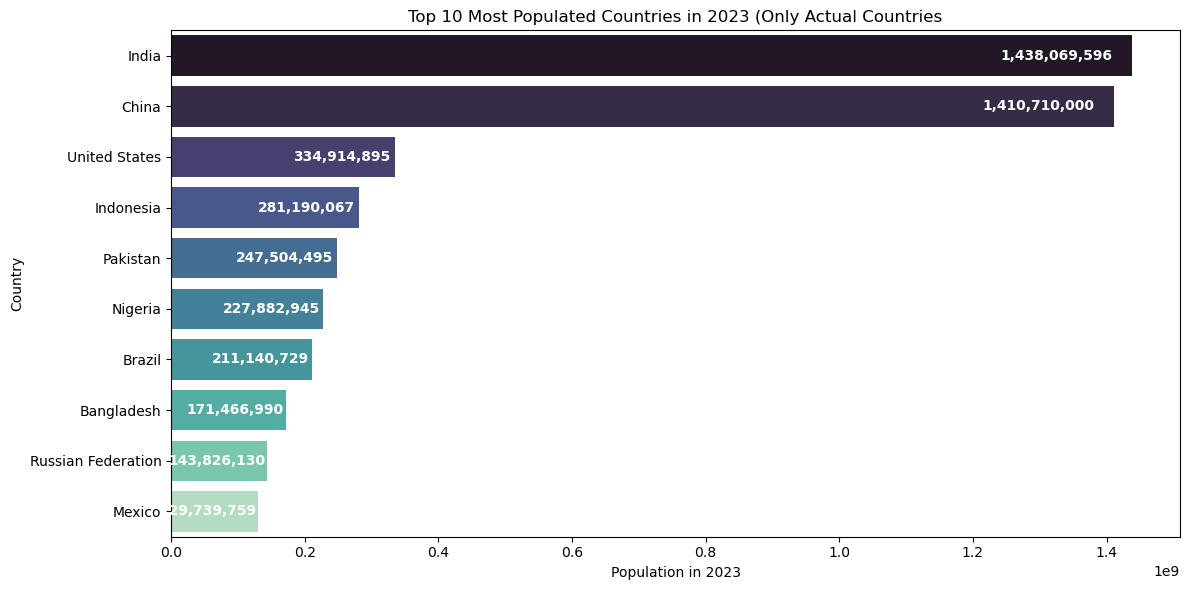

In [12]:
# List of official ISO 3166-1 alpha-3 country codes
real_country_codes = [
    'AFG', 'ALB', 'DZA', 'AND', 'AGO', 'ARG', 'ARM', 'AUS', 'AUT', 'AZE', 'BGD',
    'BEL', 'BFA', 'BGR', 'BHR', 'BIH', 'BLR', 'BLZ', 'BOL', 'BRA', 'BRN', 'BTN',
    'BWA', 'CAF', 'CAN', 'CHE', 'CHL', 'CHN', 'CMR', 'COD', 'COG', 'COL', 'COM',
    'CPV', 'CRI', 'CUB', 'CYP', 'CZE', 'DEU', 'DJI', 'DNK', 'DOM', 'DZA', 'ECU',
    'EGY', 'ERI', 'ESP', 'EST', 'ETH', 'FIN', 'FJI', 'FRA', 'GAB', 'GBR', 'GEO',
    'GHA', 'GIN', 'GMB', 'GNB', 'GRC', 'GTM', 'GUY', 'HND', 'HRV', 'HTI', 'HUN',
    'IDN', 'IND', 'IRL', 'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JOR', 'JPN',
    'KAZ', 'KEN', 'KGZ', 'KHM', 'KOR', 'KWT', 'LAO', 'LBN', 'LBR', 'LBY', 'LKA',
    'LSO', 'LTU', 'LUX', 'LVA', 'MAR', 'MDA', 'MDG', 'MDV', 'MEX', 'MKD', 'MLI',
    'MLT', 'MMR', 'MNE', 'MNG', 'MOZ', 'MRT', 'MUS', 'MWI', 'MYS', 'NAM', 'NCL',
    'NER', 'NGA', 'NIC', 'NLD', 'NOR', 'NPL', 'NZL', 'OMN', 'PAK', 'PAN', 'PER',
    'PHL', 'PNG', 'POL', 'PRI', 'PRK', 'PRT', 'PRY', 'QAT', 'ROU', 'RUS', 'RWA',
    'SAU', 'SDN', 'SEN', 'SGP', 'SLB', 'SLE', 'SLV', 'SOM', 'SRB', 'SSD', 'SUR',
    'SVK', 'SVN', 'SWE', 'SWZ', 'SYR', 'TCD', 'TGO', 'THA', 'TJK', 'TKM', 'TLS',
    'TTO', 'TUN', 'TUR', 'TWN', 'TZA', 'UGA', 'UKR', 'URY', 'USA', 'UZB', 'VEN',
    'VNM', 'VUT', 'YEM', 'ZAF', 'ZMB', 'ZWE'
]

# Filter dataset using country code
df_countries = df[df['Country Code'].isin(real_country_codes)]
top_10_countries = df_countries.sort_values(by = '2023', ascending = False).head(10)

# Plot Bar chart
plt.figure(figsize = (12, 6))
sns.barplot(x = '2023', y = 'Country Name', data = top_10_countries, hue = 'Country Name', palette = 'mako', legend = False)

# Add value labels (formatted with commas)
for index, value in enumerate(top_10_countries['2023']) :
    plt.text(value * 0.98, index, f'{int(value):,}', va = 'center', ha = 'right', fontsize = 10, color = 'white', fontweight = 'bold')

plt.xlabel("Population in 2023")
plt.ylabel("Country")
plt.title("Top 10 Most Populated Countries in 2023 (Only Actual Countries")
plt.tight_layout()
plt.show()

##### **- This dataset contains not just countries, but also aggregated regions or groups like : World, South Asia, IDA & IBRD total, High income, Europe & Central Asia, etc.**
##### **- To reliably include only real countries, we used the official ISO 3166-1 alpha-3 codes, which is a recognized international standard.**
##### **- Population in 2023 : As India is the most populated country (~ 1.43 billion) & China is the 2nd (~ 1.41 billion)**

#### **3.2 : Histogram - Distribution of Country Populations in 2023.**

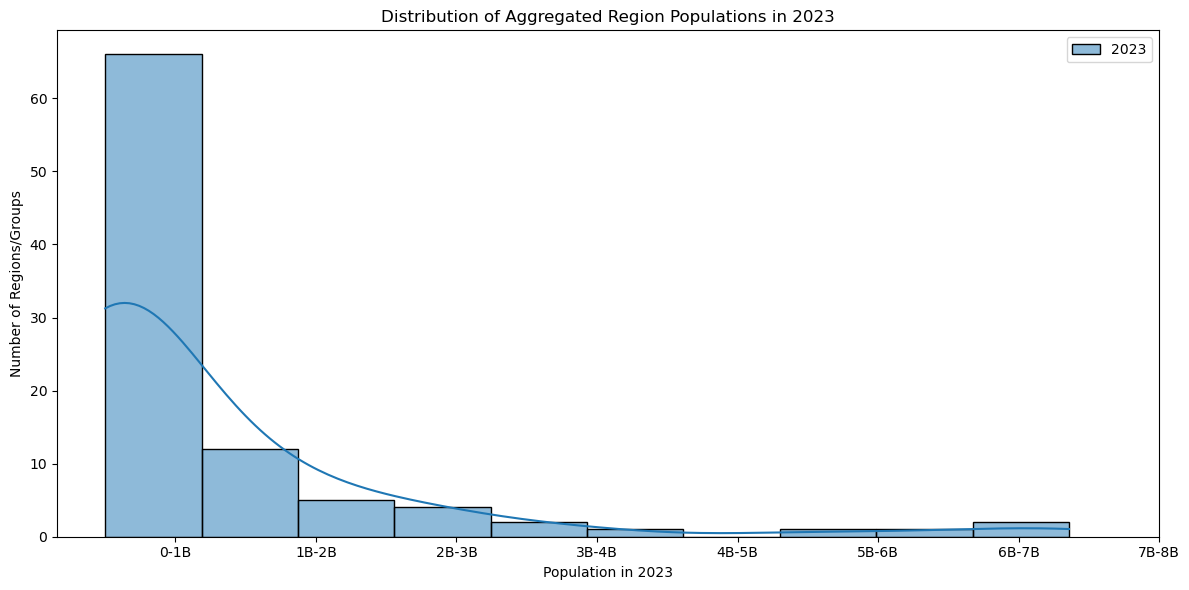

In [32]:
# Filter Non-country rows i.e., aggregated regions or groups
non_countries = df[~df['Country Code'].isin(real_country_codes)]

# Extract 2023 population
non_countries_population = non_countries[['Country Name', '2023']].dropna()

# Filter
non_countries_population = non_countries_population[non_countries_population['Country Name'] != 'World']

# Defining simple bin edges (1e9 = 1 X 10^9 = 1,000,000,000 (1 billion))
bins = [0, 1e9, 2e9, 3e9, 4e9, 5e9, 6e9, 7e9, 8e9, 9e9]

# Histogram
plt.figure(figsize = (12, 6))
sns.histplot(non_countries_population, bins = 10, kde = True, color = 'blue')

# Readable labels
labels = ['0-1B', '1B-2B', '2B-3B', '3B-4B', '4B-5B', '5B-6B', '6B-7B', '7B-8B']
plt.xticks(ticks = [(bins[i] + bins[i+1]) / 2 for i in range(len(labels))], labels = labels)
plt.xlabel("Population in 2023")
plt.ylabel("Number of Regions/Groups")
plt.title("Distribution of Aggregated Region Populations in 2023")
plt.tight_layout()
plt.show()

##### **- Majority of aggregated regions or groups have populations under 2 billion, while very few surpass 2 billion in 2023.**
##### **- Excluding the "World" group gives a more realistic and balanced view of population distribution across non-country regions.**